# Milda Branch

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df = pd.read_csv ("data/historical_data.csv")

In [83]:
target_column_name = "is_suspicious"
feature_column_names = [col for col in df.columns if col != target_column_name]
X_full = df[feature_column_names]
y_full = df[target_column_name]

print("X shape:", X_full.shape)
print("y shape:", y_full.shape)

print("\nKlassfördelning:")
print(y_full.value_counts())

print("\nKlassfördelning i procent:")
print(y_full.value_counts(normalize=True)*100)

print("\nFörsta 5 rader i datasetet:")
display(df.head())

print("\nInformation om datasetet:")
df.info()

print("\nBeskrivande statistik för numeriska kolumner:")
display(X_full.describe())

X shape: (12000, 17)
y shape: (12000,)

Klassfördelning:
is_suspicious
0    10776
1     1224
Name: count, dtype: int64

Klassfördelning i procent:
is_suspicious
0    89.8
1    10.2
Name: proportion, dtype: float64

Första 5 rader i datasetet:


,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
0,0,8,ad_post,other,urban,android,38.4,2,1,1,594.16,3,91,0,1,0,2.3,0
1,1,4,ad_post,fashion,urban,android,20.0,1,0,1,134.47,2,150,0,0,0,13.6,0
2,2,4,ad_post,other,metro,ios,46.7,3,1,1,198.52,3,72,0,0,0,4.2,0
3,3,3,ad_post,furniture,metro,android,44.3,3,1,2,141.20,3,0,0,0,0,19.8,0
4,4,1,ad_post,electronics,metro,web,211.2,5,0,0,81.39,3,9,0,0,1,23.3,0



Information om datasetet:
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          12000 non-null  int64  
 1   day                         12000 non-null  int64  
 2   event_type                  12000 non-null  str    
 3   category                    12000 non-null  str    
 4   region                      11660 non-null  str    
 5   device                      12000 non-null  str    
 6   account_age_days            12000 non-null  float64
 7   num_prev_listings           12000 non-null  int64  
 8   prev_reports_30d            12000 non-null  int64  
 9   verification_level          12000 non-null  int64  
 10  price                       11182 non-null  float64
 11  num_images                  12000 non-null  int64  
 12  message_length              12000 non-null  int64  
 13  contains_off_pl

,id,day,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,11182.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,11410.000000
mean,5999.50000,7.482667,99.632567,3.027750,0.151500,0.710167,207.348603,2.870417,111.154417,0.072833,0.099083,0.181167,22.160438
std,3464.24595,4.032520,112.903541,1.766467,0.386083,0.719171,196.226023,1.766886,66.396885,0.259874,0.298786,0.385172,28.834047
min,0.00000,1.000000,2.200000,0.000000,0.000000,0.000000,7.670000,0.000000,0.000000,0.000000,0.000000,0.000000,0.300000
25%,2999.75000,4.000000,36.300000,2.000000,0.000000,0.000000,86.195000,2.000000,63.000000,0.000000,0.000000,0.000000,6.700000
50%,5999.50000,7.000000,66.600000,3.000000,0.000000,1.000000,149.225000,3.000000,108.000000,0.000000,0.000000,0.000000,13.400000
75%,8999.25000,11.000000,120.700000,4.000000,0.000000,1.000000,256.795000,4.000000,155.000000,0.000000,0.000000,0.000000,26.600000
max,11999.00000,14.000000,2741.700000,12.000000,3.000000,2.000000,2743.080000,10.000000,416.000000,1.000000,1.000000,1.000000,579.800000


### Datasetöversikt

Datasetet innehåller 12 000 rader och 18 kolumner.

Kolumnerna innehåller både numeriska variabler och strängvariabler.

Target-kolumnen is_suspicious visar om en händelse är misstänkt (1) eller inte misstänkt (0).

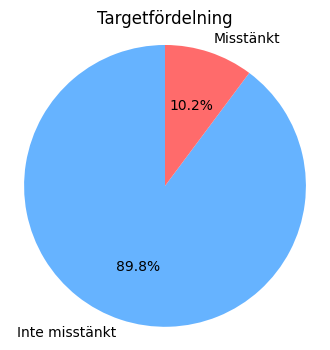

In [80]:
value = df["is_suspicious"].value_counts()

plt.figure(figsize=(4,4))
plt.pie(value,
        labels=["Inte misstänkt", "Misstänkt"],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#66b3ff',  '#FF6B6B'])

plt.title("Targetfördelning")
plt.axis('equal')

plt.show()

### Targetfördelning

Diagrammet visar att majoriteten av händelserna är icke-misstänkta - cirka 89.8%, medan ungefär 10.2% är misstänkta.   

In [79]:
print("Saknade värden:")
missing_number = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_number / len(df))*100
missing_table = pd.DataFrame ( {
    "Antal saknade värden": missing_number,
    "Andel (%)": missing_percent.round(2)
})
missing_table = missing_table[missing_table["Antal saknade värden"] > 0]
missing_table

Saknade värden:


,Antal saknade värden,Andel (%)
price,818,6.82
time_to_first_response_min,590,4.92
region,340,2.83


### Saknade värden

Datasetet innehåller saknade värden i några kolumner.   

Kolumnen price har 818  (6.82%) saknade värden.  
Kolumnen time_to_first_response_min har 590 (4.92%) saknade värden.  
Kolumnen region har 340 (2.83%) saknade värden.   


Dessa kommer att hanteras i preprocessing-steget med imputering.

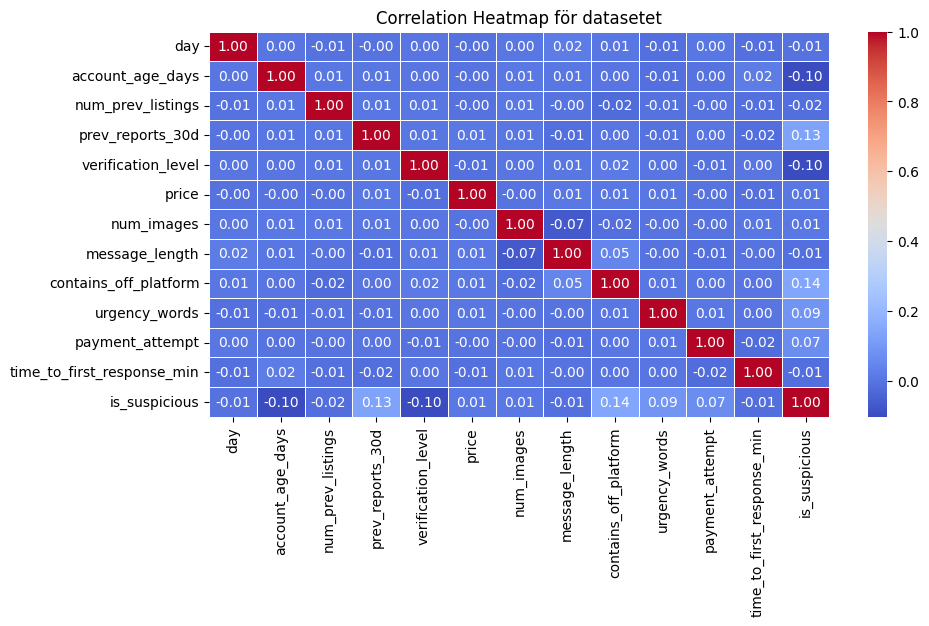

Numeriska kolumner och deras relation till target


,Relation till target
contains_off_platform,0.142
prev_reports_30d,0.131
urgency_words,0.087
payment_attempt,0.067
price,0.012
num_images,0.009
id,0.005
day,-0.008
message_length,-0.012
time_to_first_response_min,-0.014


In [69]:
corr = df.drop(columns=["id"]).select_dtypes(include="number").corr()

plt.figure(figsize=(10,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap för datasetet")
plt.show()

print("Numeriska kolumner och deras relation till target")
corr_target = df.select_dtypes(include="number").corr()[["is_suspicious"]]
corr_target = corr_target.drop("is_suspicious")
corr_target = corr_target.sort_values(by="is_suspicious", ascending=False)

corr_target = corr_target.round(3)
corr_target.columns = ["Relation till target"]

display(corr_target)

### Relation mellan numeriska kolumner och target

Correlation Heatmap och tabellen "Numeriska kolumner och deras relation till target" visar hur numeriska kolumner i datasetet relaterar till target-kolumnen is_suspicious.  

Kolumnerna contains_off_platform och prev_reports_30d visar den starkaste relationen till target.

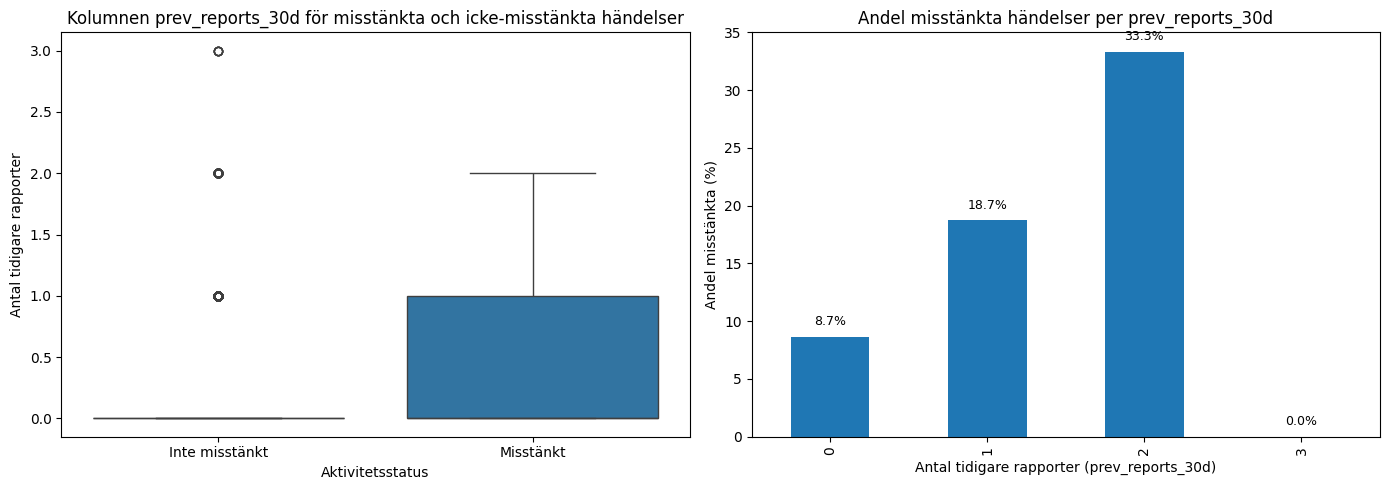

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(x="is_suspicious", y="prev_reports_30d", data=df, ax=axes[0])
axes[0].set_title("Kolumnen prev_reports_30d för misstänkta och icke-misstänkta händelser")
axes[0].set_xlabel("Aktivitetsstatus")
axes[0].set_ylabel("Antal tidigare rapporter")
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(["Inte misstänkt", "Misstänkt"])


risk = df.groupby("prev_reports_30d")["is_suspicious"].mean()*100
risk.plot(kind="bar", ax=axes[1])

axes[1].set_title("Andel misstänkta händelser per prev_reports_30d")
axes[1].set_xlabel("Antal tidigare rapporter (prev_reports_30d)")
axes[1].set_ylabel("Andel misstänkta (%)")

for i, v in enumerate(risk):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### Kolumnen prev_reports_30d för misstänkta och icke-misstänkta händelser

Diagrammet till *vänster* visar hur värden i kolumnen prev_reports_30d fördelar sig mellan misstänkta och icke-misstänkta händelser.

Det syns att misstänkta händelser oftare har högre värden i kolumnen prev_reports_30d än icke-misstänkta händelser.

Diagrammet till *höger* visar andelen misstänkta händelser beroende på antalet tidigare rapporter (prev_reports_30d).

Andelen misstänkta händelser ökar när värdet på prev_reports_30d ökar.